In [1]:
#import the telco churn data:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# ** Dataset Cleaning & Exploration **

In [3]:
import os

df = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))

# 'Churn' as target variable
y = df['Churn']
X = df.drop('Churn', axis=1)

# Convert X to a numpy array
X = X.to_numpy()

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("First 5 rows of X:\n", X[:5])
print("First 5 values of y:\n", y[:5])

Shape of features (X): (7043, 20)
Shape of target (y): (7043,)
First 5 rows of X:
 [['7590-VHVEG' 'Female' 0 'Yes' 'No' 1 'No' 'No phone service' 'DSL' 'No'
  'Yes' 'No' 'No' 'No' 'No' 'Month-to-month' 'Yes' 'Electronic check'
  29.85 '29.85']
 ['5575-GNVDE' 'Male' 0 'No' 'No' 34 'Yes' 'No' 'DSL' 'Yes' 'No' 'Yes'
  'No' 'No' 'No' 'One year' 'No' 'Mailed check' 56.95 '1889.5']
 ['3668-QPYBK' 'Male' 0 'No' 'No' 2 'Yes' 'No' 'DSL' 'Yes' 'Yes' 'No'
  'No' 'No' 'No' 'Month-to-month' 'Yes' 'Mailed check' 53.85 '108.15']
 ['7795-CFOCW' 'Male' 0 'No' 'No' 45 'No' 'No phone service' 'DSL' 'Yes'
  'No' 'Yes' 'Yes' 'No' 'No' 'One year' 'No' 'Bank transfer (automatic)'
  42.3 '1840.75']
 ['9237-HQITU' 'Female' 0 'No' 'No' 2 'Yes' 'No' 'Fiber optic' 'No' 'No'
  'No' 'No' 'No' 'No' 'Month-to-month' 'Yes' 'Electronic check' 70.7
  '151.65']]
First 5 values of y:
 0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object


In [4]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [5]:
#example of one:
print(X[:1])

[['7590-VHVEG' 'Female' 0 'Yes' 'No' 1 'No' 'No phone service' 'DSL' 'No'
  'Yes' 'No' 'No' 'No' 'No' 'Month-to-month' 'Yes' 'Electronic check'
  29.85 '29.85']]


In [6]:
first_customer = df.iloc[0]

# Prepare data for a new DataFrame to display the requested information
data = []
for col_name, value in first_customer.items():
    data.append({
        'Column Name': col_name,
        'Value': value,
        'Type': type(value).__name__
    })

# Create a DataFrame for better readability
result_df = pd.DataFrame(data)
print(result_df)

         Column Name             Value     Type
0         customerID        7590-VHVEG      str
1             gender            Female      str
2      SeniorCitizen                 0    int64
3            Partner               Yes      str
4         Dependents                No      str
5             tenure                 1    int64
6       PhoneService                No      str
7      MultipleLines  No phone service      str
8    InternetService               DSL      str
9     OnlineSecurity                No      str
10      OnlineBackup               Yes      str
11  DeviceProtection                No      str
12       TechSupport                No      str
13       StreamingTV                No      str
14   StreamingMovies                No      str
15          Contract    Month-to-month      str
16  PaperlessBilling               Yes      str
17     PaymentMethod  Electronic check      str
18    MonthlyCharges             29.85  float64
19      TotalCharges             29.85  

In [7]:
#make total charges a number, not str"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(df[['TotalCharges']].head())
print(df['TotalCharges'].dtype)

   TotalCharges
0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
float64


In [8]:
# See the unique vales for string-typed columns
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Column '{col}': {df[col].unique()}")

Column 'customerID': ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Column 'gender': ['Female' 'Male']
Column 'Partner': ['Yes' 'No']
Column 'Dependents': ['No' 'Yes']
Column 'PhoneService': ['No' 'Yes']
Column 'MultipleLines': ['No phone service' 'No' 'Yes']
Column 'InternetService': ['DSL' 'Fiber optic' 'No']
Column 'OnlineSecurity': ['No' 'Yes' 'No internet service']
Column 'OnlineBackup': ['Yes' 'No' 'No internet service']
Column 'DeviceProtection': ['No' 'Yes' 'No internet service']
Column 'TechSupport': ['No' 'Yes' 'No internet service']
Column 'StreamingTV': ['No' 'Yes' 'No internet service']
Column 'StreamingMovies': ['No' 'Yes' 'No internet service']
Column 'Contract': ['Month-to-month' 'One year' 'Two year']
Column 'PaperlessBilling': ['Yes' 'No']
Column 'PaymentMethod': ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Column 'Churn': ['No' 'Yes']


In [9]:
#drop "customerID"
df = df.drop('customerID', axis=1)

In [10]:
#see where
print("Number of null values per column in df:")
print(df.isnull().sum())

Number of null values per column in df:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
# Convert 'Churn' to numerical (0 for No, 1 for Yes)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify categorical columns (object dtype) excluding 'customerID' which was already dropped
categorical_cols = [col for col in df.columns if df[col].dtype == 'object']

# Exclude 'Churn' from one-hot encoding as it's the target variable and already handled
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# One-hot encode the remaining categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding and 'Churn' conversion:")
print(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")
print("Data types after encoding:")
print(df_encoded.dtypes.value_counts())

DataFrame after one-hot encoding and 'Churn' conversion:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1          

Range of TotalCharges: 0.0 - 8684.8
Range of MonthlyCharges: 18.25 - 118.75


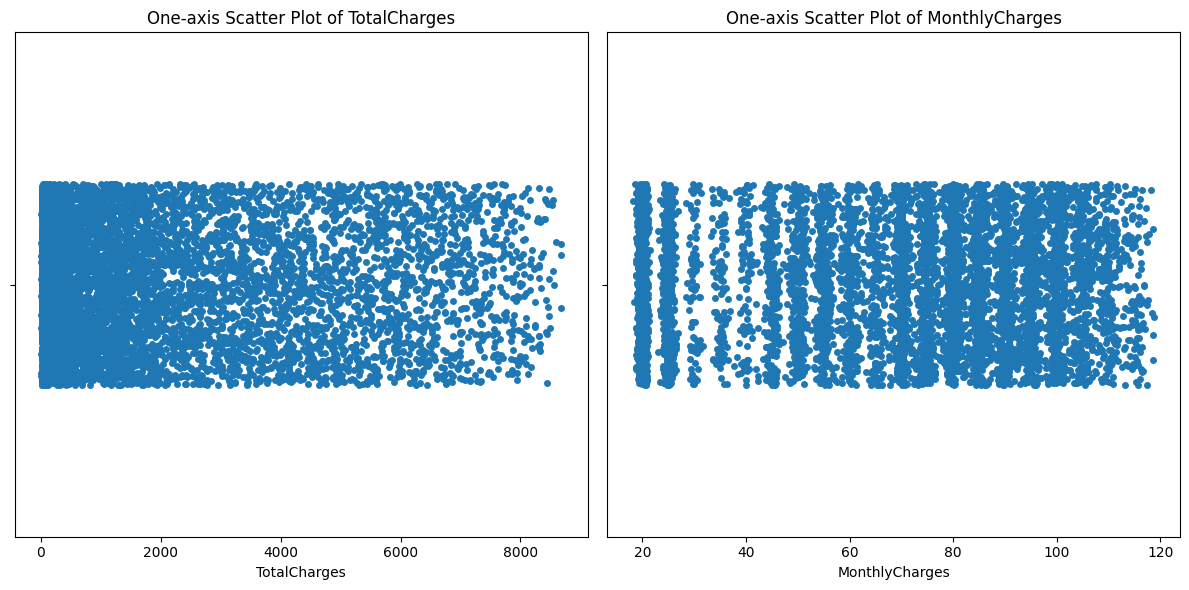

In [12]:
print(f"Range of TotalCharges: {df['TotalCharges'].min()} - {df['TotalCharges'].max()}")
print(f"Range of MonthlyCharges: {df['MonthlyCharges'].min()} - {df['MonthlyCharges'].max()}")

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.stripplot(x=df['TotalCharges'], jitter=0.2)
plt.title('One-axis Scatter Plot of TotalCharges')
plt.xlabel('TotalCharges')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.stripplot(x=df['MonthlyCharges'], jitter=0.2)
plt.title('One-axis Scatter Plot of MonthlyCharges')
plt.xlabel('MonthlyCharges')

plt.tight_layout()
plt.show()

Decision- we're going to normalize both values to [0,1],


Range of tenure: 0 - 72


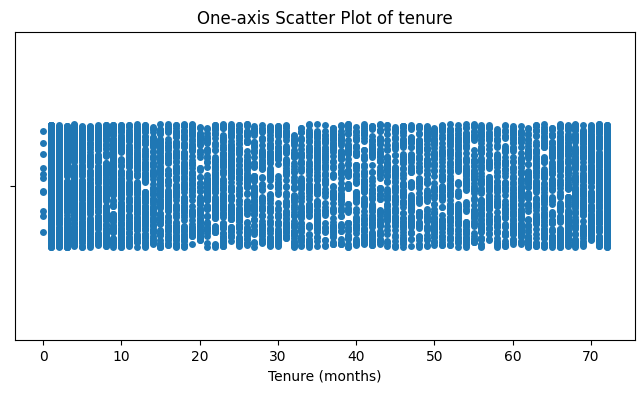

In [13]:
print(f"Range of tenure: {df['tenure'].min()} - {df['tenure'].max()}")

plt.figure(figsize=(8, 4))
sns.stripplot(x=df['tenure'], jitter=0.2)
plt.title('One-axis Scatter Plot of tenure')
plt.xlabel('Tenure (months)')
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler

# Make a copy to work on, ensuring we don't accidentally modify other variables if not intended
df_processed = df_encoded.copy()

# 1. Normalize 'tenure', 'TotalCharges', 'MonthlyCharges'
numerical_cols_to_normalize = ['tenure', 'TotalCharges', 'MonthlyCharges']
scaler = StandardScaler()
df_processed[numerical_cols_to_normalize] = scaler.fit_transform(df_processed[numerical_cols_to_normalize])

# 2. One-hot encode 'SeniorCitizen'
# Since 'SeniorCitizen' is already 0 or 1, pd.get_dummies will treat these as categories.
df_processed = pd.get_dummies(df_processed, columns=['SeniorCitizen'], prefix='SeniorCitizen', drop_first=False)

print("DataFrame after normalization and one-hot encoding of SeniorCitizen:")
print(df_processed.head())
print(f"\nNew shape of DataFrame: {df_processed.shape}")
print("\nData types after processing:")
print(df_processed.dtypes.value_counts())

DataFrame after normalization and one-hot encoding of SeniorCitizen:
     tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  Partner_Yes  \
0 -1.277445       -1.160323     -0.992611      0        False         True   
1  0.066327       -0.259629     -0.172165      0         True        False   
2 -1.236724       -0.362660     -0.958066      1         True        False   
3  0.514251       -0.746535     -0.193672      0         True        False   
4 -1.236724        0.197365     -0.938874      1        False        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           False              True                           False   
2           False              True                           False   
3           False             False                            True   
4           False              True                           False   

   MultipleLines_Yes  ...  Streamin

#**Cleaning pipeline for shared usage with team**

In [ ]:
def clean_data(raw_df):
    # 1. Create a copy to avoid SettingWithCopyWarning
    temp_df = raw_df.copy()

    # 2. Clean 'TotalCharges': convert to numeric and fill NaNs (from empty strings) with 0
    temp_df['TotalCharges'] = pd.to_numeric(temp_df['TotalCharges'], errors='coerce')
    temp_df['TotalCharges'] = temp_df['TotalCharges'].fillna(0)

    # 3. Drop 'customerID' if it exists
    if 'customerID' in temp_df.columns:
        temp_df = temp_df.drop('customerID', axis=1)

    # 4. Convert 'Churn' target to numerical (0/1) if it exists
    if 'Churn' in temp_df.columns:
        temp_df['Churn'] = temp_df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

    # 5. One-hot encode categorical string columns (excluding Churn)
    categorical_cols = [col for col in temp_df.columns if temp_df[col].dtype == 'object']
    if 'Churn' in categorical_cols: categorical_cols.remove('Churn')

    # Apply get_dummies
    temp_df = pd.get_dummies(temp_df, columns=categorical_cols, drop_first=True)

    # 6. One-hot encode 'SeniorCitizen' specifically (as requested earlier)
    if 'SeniorCitizen' in temp_df.columns:
        temp_df = pd.get_dummies(temp_df, columns=['SeniorCitizen'], prefix='SeniorCitizen', drop_first=False)

    # 7. Standardize numerical features
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    scaler = StandardScaler()
    temp_df[numerical_cols] = scaler.fit_transform(temp_df[numerical_cols])

    return temp_df

# Re-load the original data to test the pipeline
df_raw = pd.read_csv(os.path.join(path, 'WA_Fn-UseC_-Telco-Customer-Churn.csv'))
df_final = clean_data(df_raw)

display(df_final.head())
print(f"Pipeline complete. Final shape: {df_final.shape}")

#Assumption testing#